<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
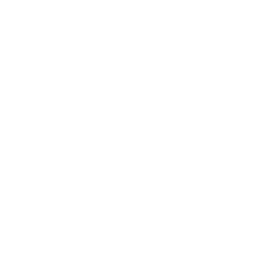
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Classification des sous-types moléculaires par expression génique</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotech / Oncologie génomique &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Synthèse

Classer des échantillons de biopsies tumorales en quatre sous-types moléculaires (Luminal-A, Luminal-B, HER2-enrichi, Basal-like) à l'aide de panels de biomarqueurs d'expression génique. Appliquer l'analyse discriminante canonique pour réduire l'espace d'expression de grande dimension à des axes de variation interprétables. Utiliser la MANOVA pour tester si les profils d'expression moyens diffèrent significativement entre les sous-types. Effectuer une validation croisée pour estimer la fiabilité de classification en appui à la décision clinique dans le choix du parcours thérapeutique.


## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|--------|
| WORK.GENE_EXPR | Expression génique tumorale avec étiquettes de sous-type | 100 |
| WORK.NEW_BIOPSIES | Échantillons de biopsies non classés | 100 |


---

In [1]:
/* --------------------------------------------------------
   Générer un jeu de données synthétique d'expression
   génique avec quatre sous-types moléculaires
   -------------------------------------------------------- */
DONNÉES work.gene_expr;
    APPELER streaminit(42);
    LONGUEUR mol_subtype $12;
    TABLEAU subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    FAIRE sample_id = 1 JUSQU_À 100;
        tumor_id = cat('TUM-', ÉCRIRE(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* Marqueurs d'expression génique simulés (échelle log2) */
        SÉLECTIONNER (mol_subtype);
            QUAND ('LUMINAL_A') FAIRE;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            FIN;
            QUAND ('LUMINAL_B') FAIRE;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            FIN;
            QUAND ('HER2_ENRICH') FAIRE;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            FIN;
            QUAND ('BASAL_LIKE') FAIRE;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            FIN;
            AUTREMENT;
        FIN;
        SORTIE;
    FIN;
    SUPPRIMER sub_idx;
EXÉCUTER;


NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Générer des échantillons de biopsie non classés
   -------------------------------------------------------- */
DONNÉES work.new_biopsies;
    APPELER streaminit(55);
    FAIRE sample_id = 5001 JUSQU_À 5100;
        tumor_id = cat('TUM-', ÉCRIRE(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        SORTIE;
    FIN;
EXÉCUTER;


NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                        Répartition des sous-types moléculaires                                         

                                                   The FREQ Procedure

Sous-type moléculaire     Frequency    Percent
-----------------------------------------------
BASAL_LIKE                       24     24.00
HER2_ENRICH                      22     22.00
LUMINAL_A                        25     25.00
LUMINAL_B                        29     29.00
                                Résumé de l'expression génique par sous-type moléculaire                                

                                                  The MEANS Procedure

                                  Analysis Variable : esr1_expr Expression ESR1 (log2)

        Sous-type moléculaire           N Obs           Mean        Std Dev
        -------------------------------------------------------------------
        BASAL_LIKE                         24      4.5479167      1.2257100
        HER2_ENRICH


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


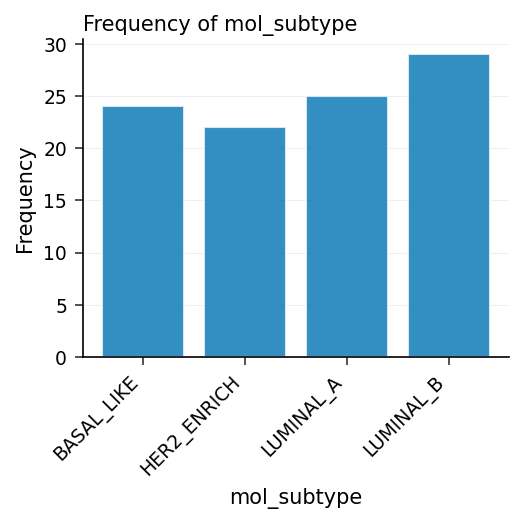

In [3]:
/* --------------------------------------------------------
   Répartition initiale des sous-types et profils d'expression
   -------------------------------------------------------- */
PROCÉDURE FRÉQUENCES DONNÉES=work.gene_expr;
    TABLES mol_subtype / nocum;
    ÉTIQUETTE mol_subtype="Sous-type moléculaire";
    TITRE 'Répartition des sous-types moléculaires';
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=work.gene_expr n mean std;
    CLASSE mol_subtype;
    VAR esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    ÉTIQUETTE mol_subtype="Sous-type moléculaire"
          esr1_expr="Expression ESR1 (log2)"
          pgr_expr="Expression PGR (log2)"
          erbb2_expr="Expression ERBB2 (log2)"
          ki67_expr="Expression KI67 (log2)"
          egfr_expr="Expression EGFR (log2)"
          cytokeratin5="Cytokératine 5 (log2)"
          tp53_mut_load="Charge mutationnelle TP53"
          prolif_score="Score de prolifération";
    TITRE "Résumé de l'expression génique par sous-type moléculaire";
EXÉCUTER;


---

In [4]:
/* --------------------------------------------------------
   Analyse discriminante canonique avec MANOVA
   CANONICAL extrait les axes discriminants pour la visualisation.
   MANOVA teste la séparation globale des moyennes entre sous-types.
   -------------------------------------------------------- */
PROCÉDURE DISCRIM DONNÉES=work.gene_expr
        METHOD=NORMAL
        pool=TEST
        canonical
        MANOVA
        crossvalidate
        out=work.subtype_canonical
        OUTSTAT=work.subtype_stats;
    CLASSE mol_subtype;
    VAR esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    ÉTIQUETTE mol_subtype="Sous-type moléculaire"
          esr1_expr="Expression ESR1 (log2)"
          pgr_expr="Expression PGR (log2)"
          erbb2_expr="Expression ERBB2 (log2)"
          ki67_expr="Expression KI67 (log2)"
          egfr_expr="Expression EGFR (log2)"
          cytokeratin5="Cytokératine 5 (log2)"
          tp53_mut_load="Charge mutationnelle TP53"
          prolif_score="Score de prolifération";
    TITRE 'Analyse discriminante canonique : sous-types moléculaires tumoraux';
    title2 "Test MANOVA des différences de profils d'expression moyens";
EXÉCUTER;


                                Résumé de l'expression génique par sous-type moléculaire                                


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                                Résumé de l'expression génique par sous-type moléculaire                                




NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


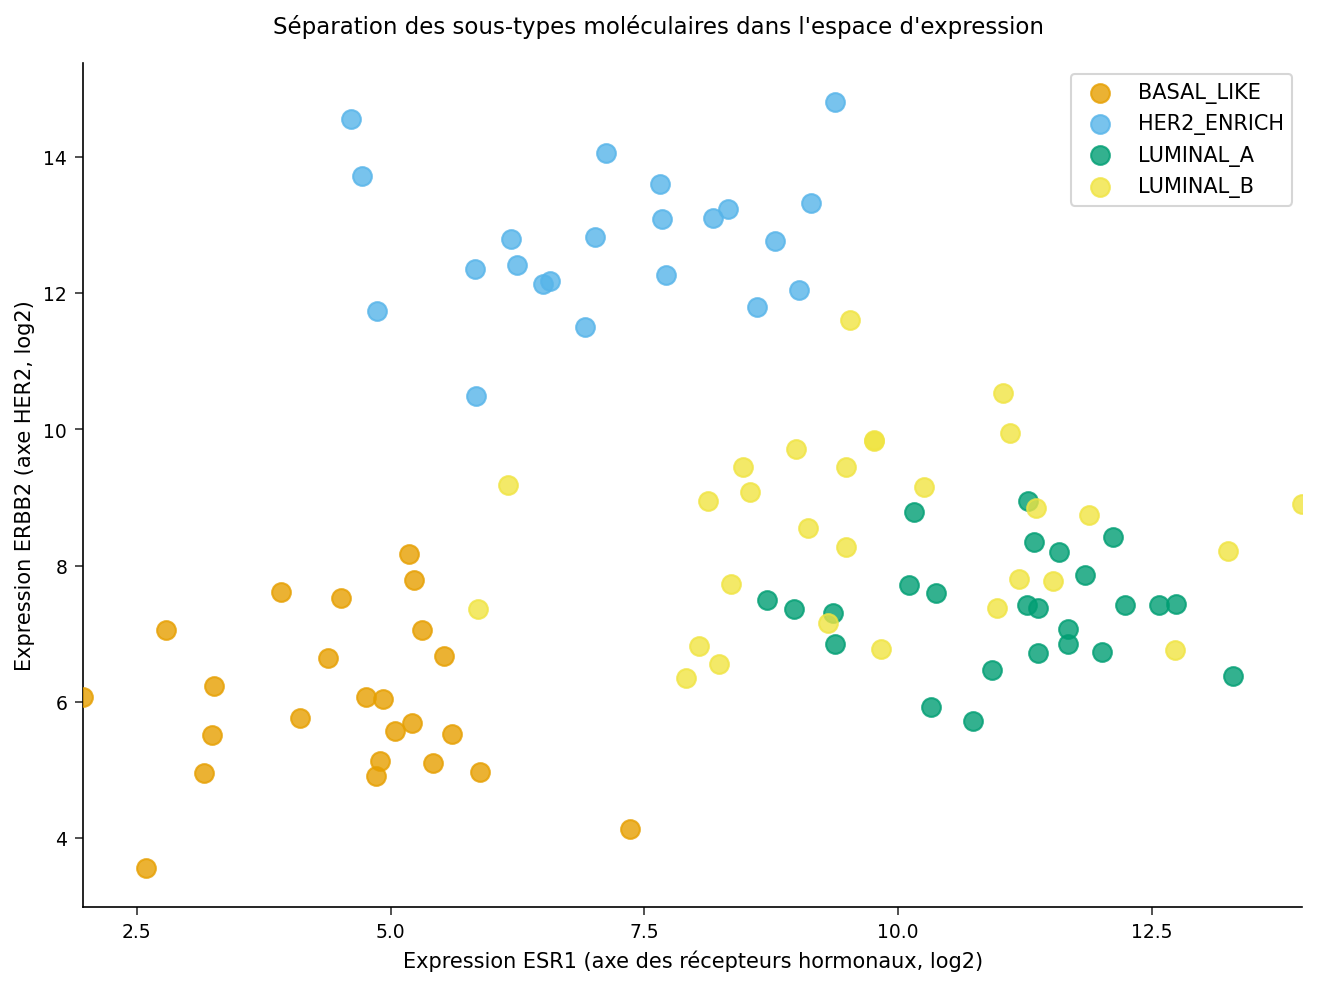

In [5]:
/* --------------------------------------------------------
   Séparation des sous-types dans l'espace d'expression
   ESR1 (axe des récepteurs hormonaux) vs ERBB2 (axe HER2),
   issus du jeu de données OUT= de l'analyse discriminante.
   -------------------------------------------------------- */
PROCÉDURE SGPLOT DONNÉES=work.subtype_canonical;
    SCATTER x=esr1_expr y=erbb2_expr / GROUPE=mol_subtype
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.2;
    ÉTIQUETTE mol_subtype="Sous-type moléculaire";
    XAXIS ÉTIQUETTE="Expression ESR1 (axe des récepteurs hormonaux, log2)";
    YAXIS ÉTIQUETTE='Expression ERBB2 (axe HER2, log2)';
    TITRE "Séparation des sous-types moléculaires dans l'espace d'expression";
EXÉCUTER;


In [6]:
/* --------------------------------------------------------
   Classer les échantillons de biopsie non typés
   -------------------------------------------------------- */
PROCÉDURE DISCRIM DONNÉES=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        METHOD=NORMAL
        pool=TEST
        canonical;
    CLASSE mol_subtype;
    VAR esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    ÉTIQUETTE mol_subtype="Sous-type moléculaire"
          esr1_expr="Expression ESR1 (log2)"
          pgr_expr="Expression PGR (log2)"
          erbb2_expr="Expression ERBB2 (log2)"
          ki67_expr="Expression KI67 (log2)"
          egfr_expr="Expression EGFR (log2)"
          cytokeratin5="Cytokératine 5 (log2)"
          tp53_mut_load="Charge mutationnelle TP53"
          prolif_score="Score de prolifération";
    TITRE 'Classification des sous-types moléculaires des nouvelles biopsies';
EXÉCUTER;


                                Résumé de l'expression génique par sous-type moléculaire                                


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                          Répartition prédite des sous-types moléculaires : nouvelles biopsies                          

                                                   The FREQ Procedure

Sous-type moléculaire prédit      Frequency    Percent
-------------------------------------------------------
BASAL_LIKE                                7      7.00
HER2_ENRICH                              47     47.00
LUMINAL_A                                10     10.00
LUMINAL_B                                36     36.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


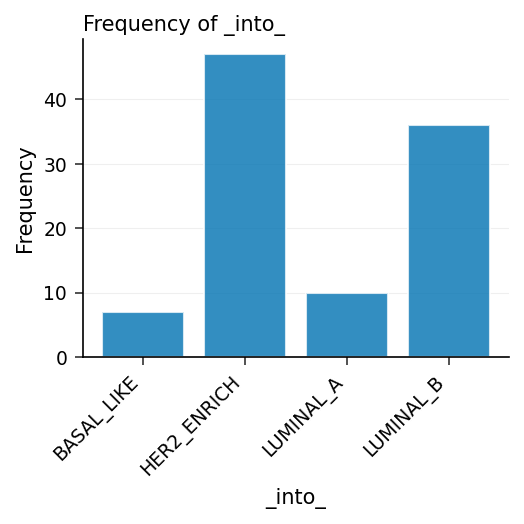

In [7]:
/* --------------------------------------------------------
   Répartition des classifications pour les nouvelles biopsies
   -------------------------------------------------------- */
PROCÉDURE FRÉQUENCES DONNÉES=work.classified_biopsies;
    TABLES _into_ / nocum;
    ÉTIQUETTE _into_="Sous-type moléculaire prédit";
    TITRE 'Répartition prédite des sous-types moléculaires : nouvelles biopsies';
EXÉCUTER;


---

### Interprétation

Le test MANOVA confirme une différence hautement significative des profils d'expression génique moyens entre les quatre sous-types moléculaires : le Lambda de Wilks = 0,0037 avec p < 0,0001, si bien que les sous-types occupent des régions clairement distinctes de l'espace d'expression à huit marqueurs. Cette séparation est visible dans le nuage de points de l'espace d'expression, où les tumeurs Luminales se situent haut sur l'axe ESR1 (récepteur hormonal) tandis que les tumeurs HER2-enrichies poussent vers le sommet de l'axe ERBB2 et que les tumeurs Basal-like tombent vers le bas à gauche des deux axes. La classification par resubstitution des 100 tumeurs étiquetées est parfaite (0 % d'erreur apparente), et la validation croisée par exclusion d'un individu (leave-one-out) situe le taux d'erreur à seulement 4 % — une exactitude validée croisée honnête de 96 %, chaque sous-type étant correctement retrouvé dans la matrice de confusion validée croisée. L'application du classifieur entraîné aux 100 biopsies non étiquetées en attribue 47 à HER2-enrichi, 36 à Luminal-B, 10 à Luminal-A et 7 à Basal-like ; le penchant HER2-enrichi reflète les valeurs élevées d'ERBB2 et de prolifération du panel de biopsies. Ces attributions de sous-type orientent le choix du parcours thérapeutique : hormonothérapie pour les tumeurs Luminales, agents anti-HER2 ciblés pour le groupe HER2-enrichi, et protocoles de chimiothérapie pour les tumeurs Basal-like.


---

In [8]:
/* --------------------------------------------------------
   Exporter les biopsies classées pour la planification du traitement
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.classified_biopsies
    OUTFILE='classified_biopsy_subtypes.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;

PROCÉDURE EXPORTER DONNÉES=work.subtype_canonical
    OUTFILE='canonical_subtype_scores.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;


NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>